#  Customer Churn Prediction — End-to-End ML Pipeline
**Dataset:** Telco Customer Churn (7,043 customers, 21 features)  
**Goal:** Predict which customers are likely to churn and explain why.

**Pipeline:**
1. Data Cleaning  2. EDA  3. Feature Engineering  4. Model Training (LR, RF, XGBoost)  5. Hyperparameter Tuning  6. Model Comparison  7. Save Model → Streamlit App


## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
import joblib

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

## 1. Data Loading & Cleaning
We load the Telco dataset and fix known issues:
- **TotalCharges** column is stored as string with spaces instead of floats → convert to numeric
- 11 customers with `TotalCharges == ' '` have `tenure=0` (new customers) → fill with `0.0`
- Drop `customerID` (unique identifier, no predictive value)


In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Fix TotalCharges: spaces → NaN → droping
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Null values: {df.isnull().sum().sum()}")
print(f"Duplicates : {df.duplicated().sum()}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

Null values: 0
Duplicates : 22

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.6%


## 2. Feature Engineering
We create **5 new features** to improve model performance:

| Feature | Description | Why it helps |
|---|---|---|
| `AvgMonthlySpend` | TotalCharges / (tenure+1) | Captures true spending rate |
| `tenure_group` | Binned tenure (0-12, 13-24, 25-48, 49+) | Captures lifecycle stage |
| `IsNewCustomer` | tenure ≤ 3 months | New customers churn more |
| `NumAddons` | Count of 6 add-on services | Stickiness signal |
| `HasMultipleServices` | NumAddons ≥ 3 | Bundled customers stay longer |


In [4]:
# Avg monthly spend
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Tenure group
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49+ months'],
    include_lowest=True)

# Is new customer ?
df['IsNewCustomer'] = (df['tenure'] <= 3).astype(int)

# Count add-on services
addons = ['OnlineSecurity','OnlineBackup','DeviceProtection',
          'TechSupport','StreamingTV','StreamingMovies']
for col in addons:
    df[col + '_bin'] = (df[col] == 'Yes').astype(int)
df['NumAddons'] = df[[c + '_bin' for c in addons]].sum(axis=1)
df.drop([c + '_bin' for c in addons], axis=1, inplace=True)

# Has multiple services?
df['HasMultipleServices'] = (df['NumAddons'] >= 3).astype(int)

print(f"New shape: {df.shape}")
df[['AvgMonthlySpend','tenure_group','IsNewCustomer','NumAddons','HasMultipleServices']].head(5)

New shape: (7032, 25)


,AvgMonthlySpend,tenure_group,IsNewCustomer,NumAddons,HasMultipleServices
0,14.925000,0-12 months,1,1,0
1,53.985714,25-48 months,0,2,0
2,36.050000,0-12 months,1,2,0
3,40.016304,25-48 months,0,3,1
4,50.550000,0-12 months,1,0,0


## 3. Exploratory Data Analysis (EDA)
We explore patterns in the data to understand what drives churn.

**Key questions:**
- What % of customers churn?
- Which contract types have highest churn?
- How does tenure relate to churn?
- Which features correlate with each other?


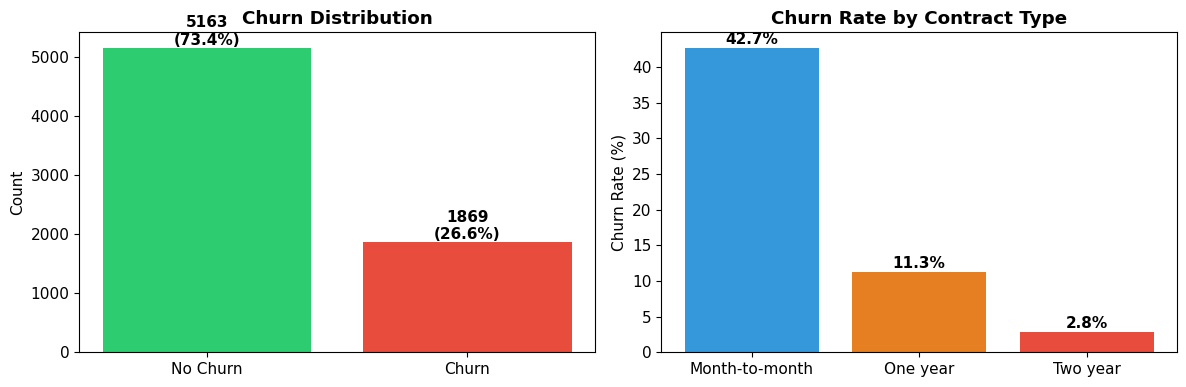

 Month-to-month contracts have MUCH higher churn than annual contracts


In [5]:
# 3a. Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Churn'].value_counts()
axes[0].bar(['No Churn','Churn'], counts.values, color=['#2ecc71','#e74c3c'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v+50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Churn rate by contract type
churn_contract = df.groupby('Contract')['Churn'].mean() * 100
axes[1].bar(churn_contract.index, churn_contract.values,
            color=['#3498db','#e67e22','#e74c3c'])
for i, v in enumerate(churn_contract.values):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

# Key insight
print(" Month-to-month contracts have MUCH higher churn than annual contracts")

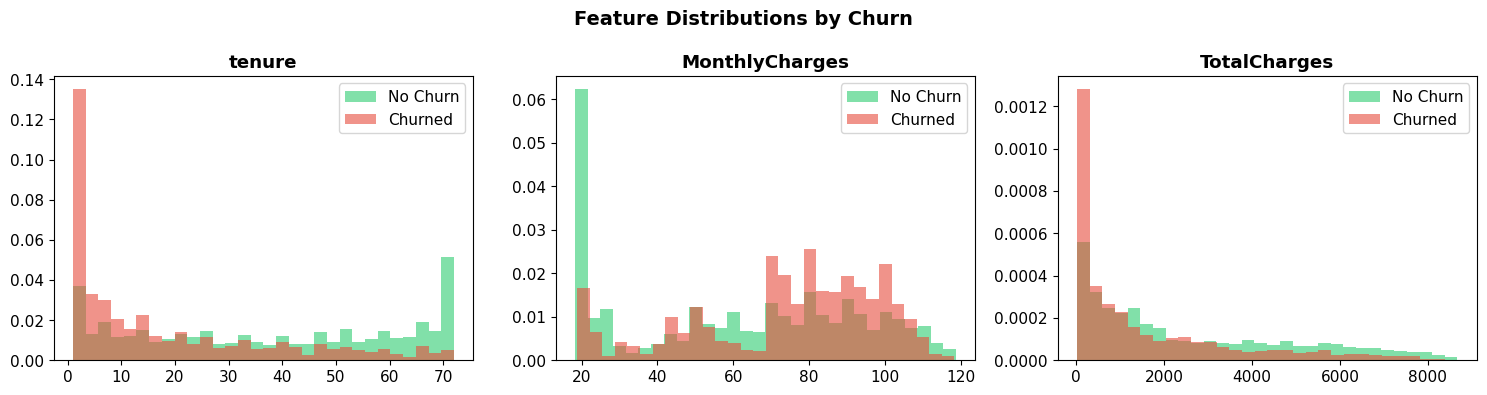

In [6]:
# 3b. Numerical Distributions by Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    for val, color, lbl in [(0,'#2ecc71','No Churn'), (1,'#e74c3c','Churned')]:
        ax.hist(df[df['Churn']==val][col], bins=30, alpha=0.6, color=color,
                label=lbl, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend()
fig.suptitle('Feature Distributions by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

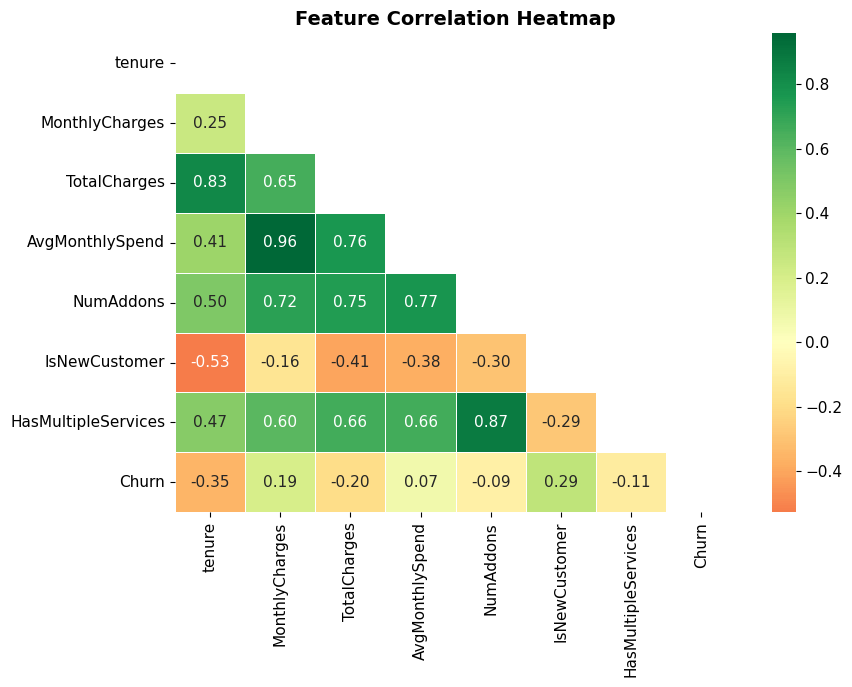

tenure is negatively correlated with Churn → loyal customers stay


In [7]:
# 3c. Correlation Heatmap
num_cols = ['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend',
            'NumAddons','IsNewCustomer','HasMultipleServices','Churn']
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("tenure is negatively correlated with Churn → loyal customers stay")

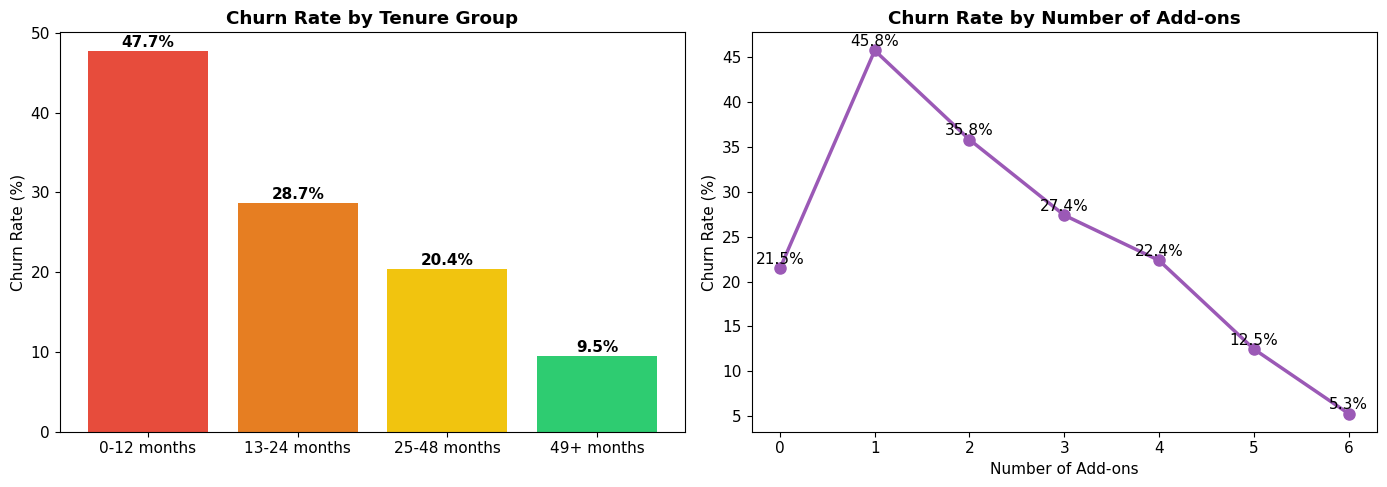

In [8]:
# 3d. Churn Rate by Tenure Group and Addons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = df.groupby('tenure_group', observed=True)['Churn'].mean().reset_index()
ct['Churn'] *= 100
axes[0].bar(ct['tenure_group'].astype(str), ct['Churn'],
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'])
for i, v in enumerate(ct['Churn']):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')

ca = df.groupby('NumAddons')['Churn'].mean().reset_index()
ca['Churn'] *= 100
axes[1].plot(ca['NumAddons'], ca['Churn'], marker='o', color='#9b59b6', linewidth=2.5, markersize=8)
for _, row in ca.iterrows():
    axes[1].text(row['NumAddons'], row['Churn']+0.5, f"{row['Churn']:.1f}%", ha='center')
axes[1].set_title('Churn Rate by Number of Add-ons', fontweight='bold')
axes[1].set_xlabel('Number of Add-ons')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticks(range(7))
plt.tight_layout()
plt.show()

## 4. Model Training

###  Class Imbalance Fix
The dataset has **26.5% churn** (imbalanced). Without fixing this, models learn to predict "No Churn" for everything and get 73% accuracy by doing nothing useful.

**Fix applied:**
- Logistic Regression & Random Forest: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = count(No) / count(Yes) ≈ 2.77`

This forces the model to pay more attention to churned customers.


In [9]:
# Define feature groups
numerical_cols = ['tenure','MonthlyCharges','TotalCharges',
                  'AvgMonthlySpend','NumAddons','IsNewCustomer','HasMultipleServices']
categorical_cols = ['gender','SeniorCitizen','Partner','Dependents',
                    'PhoneService','MultipleLines','InternetService',
                    'OnlineSecurity','OnlineBackup','DeviceProtection',
                    'TechSupport','StreamingTV','StreamingMovies',
                    'Contract','PaperlessBilling','PaymentMethod','tenure_group']

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")

# Preprocessor: scale numericals, OHE categoricals
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
], remainder='drop')

Train: (5625, 24)  |  Test: (1407, 24)
Train churn rate: 26.6%


In [10]:
#  Logistic Regression 
lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)
lr_prob = lr_pipe.predict_proba(X_test)[:,1]
print("Logistic Regression trained ")
print(classification_report(y_test, lr_pred, target_names=['No Churn','Churn']))

Logistic Regression trained 
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [11]:
#  Random Forest 
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42,
                                   class_weight='balanced', n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_prob = rf_pipe.predict_proba(X_test)[:,1]
print("Random Forest trained ")
print(classification_report(y_test, rf_pred, target_names=['No Churn','Churn']))

Random Forest trained 
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [12]:
#  XGBoost with scale_pos_weight
neg, pos = (y_train==0).sum(), (y_train==1).sum()
scale_pw = neg / pos
print(f"scale_pos_weight = {scale_pw:.2f}")

xgb_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(random_state=42, eval_metric='logloss',
                           scale_pos_weight=scale_pw, verbosity=0))
])
xgb_pipe.fit(X_train, y_train)
xgb_pred = xgb_pipe.predict(X_test)
xgb_prob = xgb_pipe.predict_proba(X_test)[:,1]
print("XGBoost trained ")
print(classification_report(y_test, xgb_pred, target_names=['No Churn','Churn']))

scale_pos_weight = 2.76
XGBoost trained 
              precision    recall  f1-score   support

    No Churn       0.87      0.78      0.82      1033
       Churn       0.52      0.67      0.59       374

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.75      0.76      1407



## 5. Hyperparameter Tuning (XGBoost)
We use `RandomizedSearchCV` with 5-fold cross-validation to find the best XGBoost hyperparameters.  
We optimize for **ROC-AUC** because it best measures ranking quality in imbalanced classification.


In [13]:
param_dist = {
    'clf__n_estimators':     [100, 200, 300],
    'clf__max_depth':        [3, 5, 7],
    'clf__learning_rate':    [0.01, 0.05, 0.1],
    'clf__subsample':        [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0]
}
xgb_pipe2 = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(random_state=42, eval_metric='logloss',
                           scale_pos_weight=scale_pw, verbosity=0))
])
rscv = RandomizedSearchCV(xgb_pipe2, param_dist, n_iter=20, scoring='roc_auc',
                           cv=5, random_state=42, n_jobs=-1, verbose=1)
rscv.fit(X_train, y_train)

print(f"Best params : {rscv.best_params_}")
print(f"Best CV AUC : {rscv.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'clf__subsample': 0.8, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}
Best CV AUC : 0.8485


In [14]:
best_model = rscv.best_estimator_
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, best_pred, target_names=['No Churn','Churn']))

              precision    recall  f1-score   support

    No Churn       0.92      0.69      0.79      1033
       Churn       0.49      0.83      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.70      1407
weighted avg       0.80      0.73      0.74      1407



## 6. Model Comparison
We compare all 4 models across 5 metrics. 

**Note on Recall vs Accuracy:**  
In churn prediction, **Recall** is often more important than Accuracy.  
A false negative (predicting "stays" when customer actually churns) costs more than a false positive.


In [15]:
results = {
    'Model': ['Logistic Regression','Random Forest','XGBoost (default)','XGBoost (tuned)'],
    'Accuracy':  [accuracy_score(y_test,lr_pred), accuracy_score(y_test,rf_pred),
                  accuracy_score(y_test,xgb_pred), accuracy_score(y_test,best_pred)],
    'Precision': [precision_score(y_test,lr_pred), precision_score(y_test,rf_pred),
                  precision_score(y_test,xgb_pred), precision_score(y_test,best_pred)],
    'Recall':    [recall_score(y_test,lr_pred), recall_score(y_test,rf_pred),
                  recall_score(y_test,xgb_pred), recall_score(y_test,best_pred)],
    'F1 Score':  [f1_score(y_test,lr_pred), f1_score(y_test,rf_pred),
                  f1_score(y_test,xgb_pred), f1_score(y_test,best_pred)],
    'ROC AUC':   [roc_auc_score(y_test,lr_prob), roc_auc_score(y_test,rf_prob),
                  roc_auc_score(y_test,xgb_prob), roc_auc_score(y_test,best_prob)]
}
comp_df = pd.DataFrame(results).round(4)
comp_df.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1 Score','ROC AUC'],
    color='lightgreen'
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.728500,0.493300,0.791400,0.607800,0.838200
1,Random Forest,0.783200,0.616900,0.486600,0.544100,0.818200
2,XGBoost (default),0.749100,0.521900,0.668400,0.586200,0.809200
3,XGBoost (tuned),0.729200,0.494400,0.826200,0.618600,0.840400


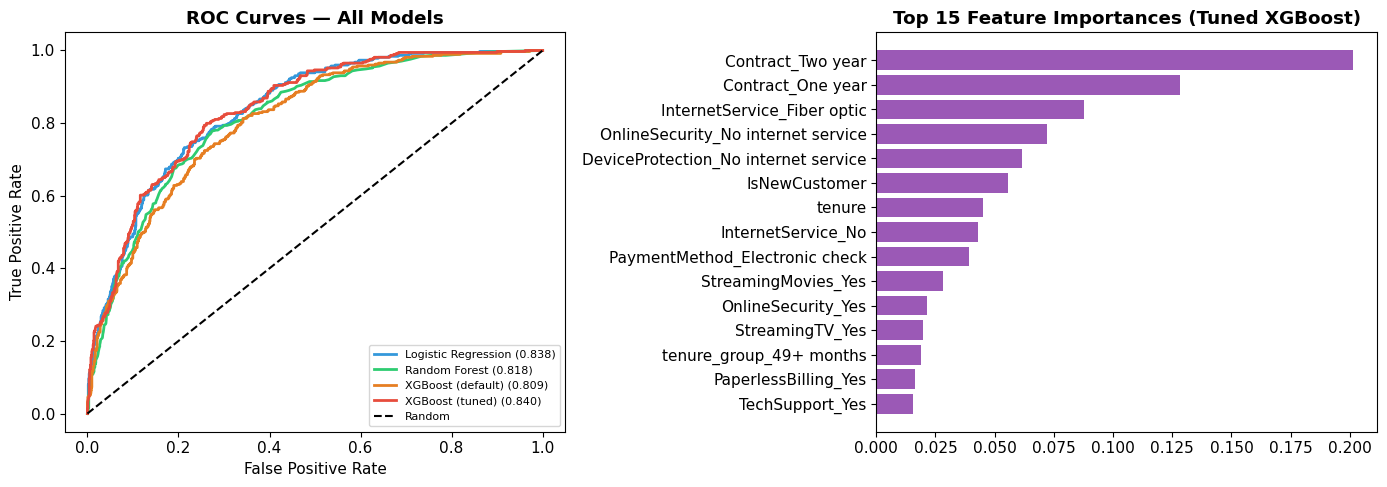

In [16]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_info = [
    (lr_prob,   'Logistic Regression', '#3498db'),
    (rf_prob,   'Random Forest',       '#2ecc71'),
    (xgb_prob,  'XGBoost (default)',   '#e67e22'),
    (best_prob, 'XGBoost (tuned)',     '#e74c3c'),
]
for prob, name, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_test,prob):.3f})',
                 color=color, linewidth=2)
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=8)

# Feature importance
xgb_clf = best_model.named_steps['clf']
pre_step = best_model.named_steps['pre']
cat_names = pre_step.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_names = numerical_cols + cat_names
feat_df = pd.DataFrame({'Feature': all_names, 'Importance': xgb_clf.feature_importances_})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)
axes[1].barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='#9b59b6')
axes[1].set_title('Top 15 Feature Importances (Tuned XGBoost)', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


## 8. Model Explainability with SHAP
#
# Accuracy tells us HOW WELL the model performs. SHAP tells us WHY it makes
# each prediction — critical for stakeholder trust and understanding which
# customer behaviors actually drive churn.

In [22]:
import shap

# Get the trained classifier and preprocessor from the pipeline
preprocessor_step = best_model.named_steps['pre']
xgb_classifier     = best_model.named_steps['clf']

# Transform a sample of test data (SHAP needs the post-encoding feature space)
X_sample = X_test.sample(300, random_state=42)
X_sample_transformed = preprocessor_step.transform(X_sample)

# Get human-readable feature names after one-hot encoding
cat_feature_names = preprocessor_step.named_transformers_['cat']\
                        .get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_feature_names

# Build explainer (TreeExplainer is fast and exact for tree-based models)
explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_sample_transformed)

print("SHAP values computed ")
print(f"Shape: {shap_values.shape}  (customers x features)")

SHAP values computed 
Shape: (300, 37)  (customers x features)


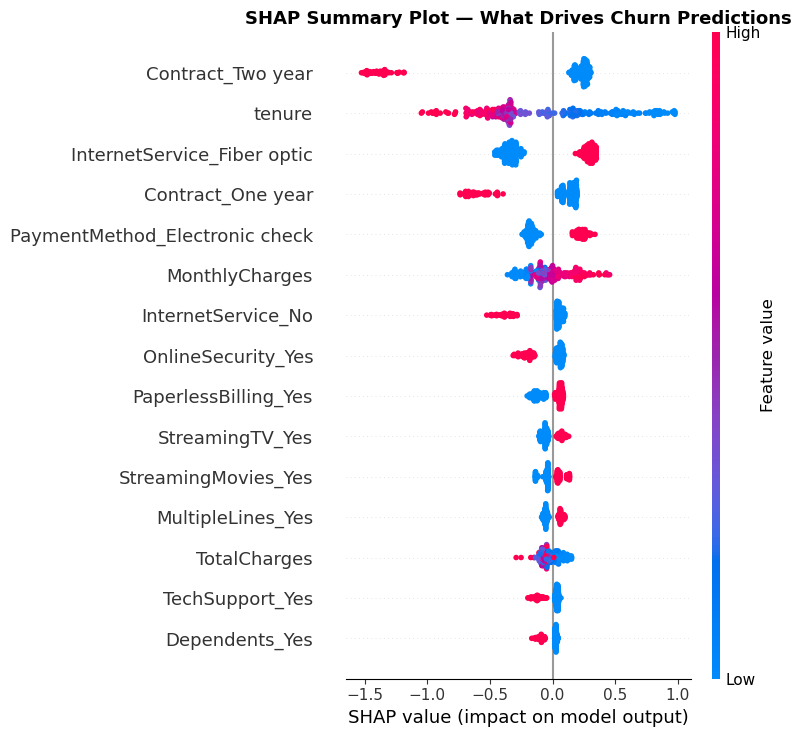


 How to read this plot:
- Each row is a feature, sorted by overall importance
- Each dot is one customer
- Red dots = high value, Blue dots = low value
- Dots to the RIGHT = pushed prediction toward CHURN
- Dots to the LEFT  = pushed prediction toward NO CHURN



In [23]:
# ── 8a. Global Feature Importance — Summary (Beeswarm) Plot ──
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample_transformed,
                   feature_names=all_feature_names, max_display=15, show=False)
plt.title("SHAP Summary Plot — What Drives Churn Predictions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
 How to read this plot:
- Each row is a feature, sorted by overall importance
- Each dot is one customer
- Red dots = high value, Blue dots = low value
- Dots to the RIGHT = pushed prediction toward CHURN
- Dots to the LEFT  = pushed prediction toward NO CHURN
""")

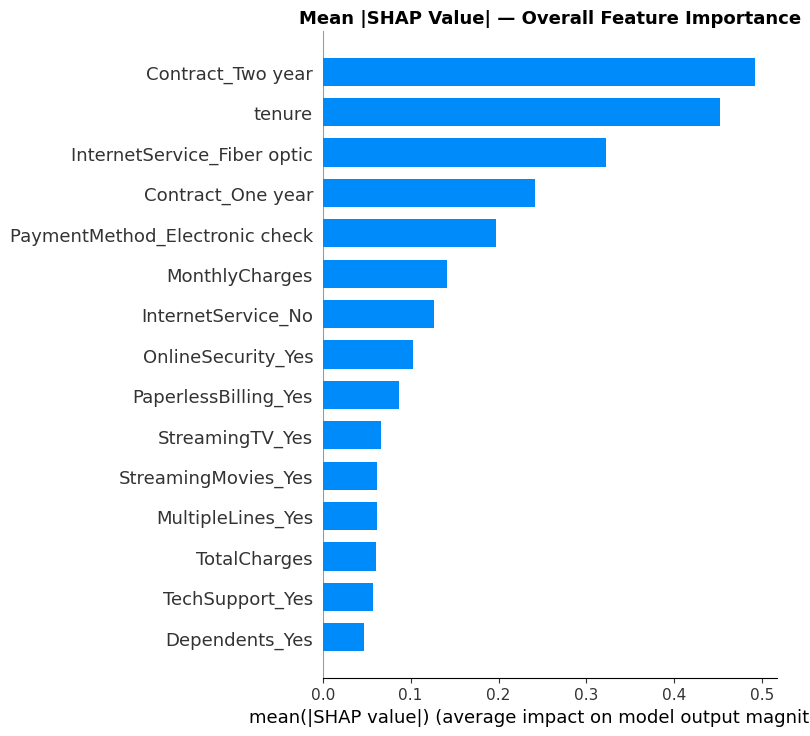

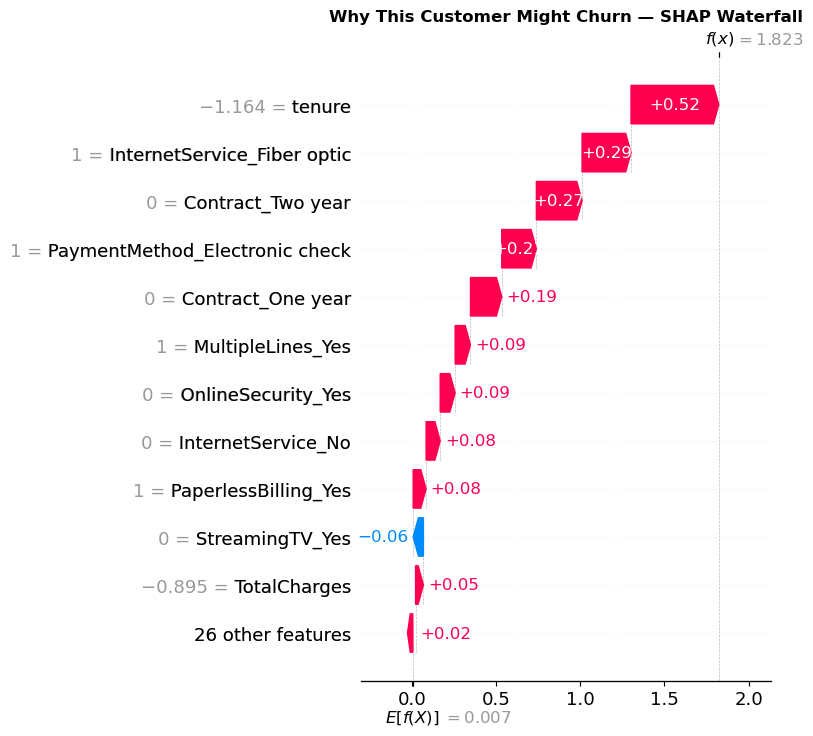

Predicted churn probability for this customer: 86.1%


In [24]:
#  8b. Global Feature Importance — Bar Plot
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_sample_transformed,
                   feature_names=all_feature_names, plot_type='bar',
                   max_display=15, show=False)
plt.title("Mean |SHAP Value| — Overall Feature Importance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#  8c. Individual Customer Explanation — Waterfall Plot
customer_idx = 0  # change this to inspect a different customer

single_explanation = shap.Explanation(
    values=shap_values[customer_idx],
    base_values=explainer.expected_value,
    data=X_sample_transformed[customer_idx],
    feature_names=all_feature_names
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(single_explanation, max_display=12, show=False)
plt.title("Why This Customer Might Churn — SHAP Waterfall", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

predicted_prob = best_model.predict_proba(X_sample.iloc[[customer_idx]])[0][1]
print(f"Predicted churn probability for this customer: {predicted_prob*100:.1f}%")

## 7. Save Best Model

In [17]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_churn_model.pkl')
print("Model saved → models/best_churn_model.pkl ")
print("Run Streamlit app: streamlit run app.py")

Model saved → models/best_churn_model.pkl 
Run Streamlit app: streamlit run app.py
